In [1]:
# === Cell 1: imports + settings ===
from __future__ import annotations

from pathlib import Path
import pickle
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# optioneel (pas later nodig)
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [3]:
# === Cell 2: load ALL pickles from folder -> single DataFrame ===
from pathlib import Path
import pickle

PICKLE_DIR = Path("/Users/jornvanbeek/Desktop/bluesky/Montecarlo")  # <-- map met pickles
PICKLE_DIR = Path('/Users/jornvanbeek/Desktop/bluesky/Montecarlo/old_errorgenerator')
DF_KEY = None  # bv "results_df" als elke pickle een dict is

def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)

dfs = []

pickle_files = sorted(PICKLE_DIR.glob("*.pkl")) + sorted(PICKLE_DIR.glob("*.pickle"))
if not pickle_files:
    raise FileNotFoundError(f"No pickle files found in {PICKLE_DIR}")

for pkl in pickle_files:
    obj = load_pickle(pkl)

    # --- haal DataFrame uit pickle ---
    if isinstance(obj, pd.DataFrame):
        df_i = obj.copy()

    elif isinstance(obj, dict):
        if DF_KEY is not None:
            if DF_KEY not in obj or not isinstance(obj[DF_KEY], pd.DataFrame):
                raise KeyError(f"{pkl.name}: DF_KEY={DF_KEY!r} not found")
            df_i = obj[DF_KEY].copy()
        else:
            for k in ("results_df", "results", "df", "data"):
                if k in obj and isinstance(obj[k], pd.DataFrame):
                    df_i = obj[k].copy()
                    break
            else:
                raise KeyError(f"{pkl.name}: no DataFrame key found")

    else:
        raise TypeError(f"{pkl.name}: unsupported pickle content {type(obj)}")

    # --- voeg configuratie-label toe ---
    # standaard: bestandsnaam zonder extensie
    df_i["config"] = pkl.stem

    dfs.append(df_i)

# combineer alles
df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(dfs)} pickles")
print("Combined shape:", df.shape)
print("Configs:", df["config"].unique())
df.head()

Loaded 15 pickles
Combined shape: (850, 84)
Configs: ['SCENARIOTEST_DELAY20' 'SCENARIOTEST_DELAY20CERTAIN'
 'SCENARIOTEST_DELAY20NOPOPUP' 'SCENARIOTEST_DELAY20_highseed'
 'SCENARIOTEST_DELAY20_rate38' 'SCENARIOTEST_DELAY25'
 'SCENARIOTEST_FCFS14' 'SCENARIOTEST_FCFS14_NOPOPUP'
 'SCENARIOTEST_FCFS14_highseed' 'SCENARIOTEST_FCFS20'
 'SCENARIOTEST_FCFS20CERTAIN' 'SCENARIOTEST_FCFS20NOPOPUP'
 'SCENARIOTEST_FCFS20_highseed' 'SCENARIOTEST_FCFS20_rate38'
 'SCENARIOTEST_FCFS25']


,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,50.980392,0.916667,1.87,5.0,3.0,UAL968SH,NaN,NaN,NaN,7,7,-504.652989,-194.704692,-15.760368,0.0,0.426471,4.0,1.673077,0.0,0.0

In [4]:
# === Cell 3: basic sanity check + harmoniseren kolomnamen ===
# Doel:
# - sample_id: identifier van dezelfde traffic sample over configs heen (repeated measures)
# - condition: de configuratie/conditie label

# 1) Als je andere namen gebruikt, map ze hier:
rename_map = {
    # voorbeelden:
    # "scenario_id": "sample_id",
    # "seed": "sample_id",
    # "config": "condition",
}
if rename_map:
    df = df.rename(columns=rename_map)

# 2) Maak/zet 'condition'
# Als je in Cell 2 'config' hebt toegevoegd (op basis van bestandsnaam),
# dan is dat doorgaans je condition.
if "condition" not in df.columns:
    if "config" in df.columns:
        df["condition"] = df["config"].astype(str)
    else:
        raise ValueError("Missing 'condition' column and no 'config' column found. Add a mapping in rename_map.")
else:
    df["condition"] = df["condition"].astype(str)

# 3) Maak/zet 'sample_id'
# Belangrijk: sample_id moet hetzelfde traffic sample aanduiden over alle conditions heen.
if "sample_id" not in df.columns:
    # probeer een paar veelvoorkomende alternatieven
    for alt in ("title", "scenario", "scenario_id", "seed", "run_id", "mc_id", "sample"):
        if alt in df.columns:
            df["sample_id"] = df[alt].astype(str)
            print(f"sample_id derived from column '{alt}'")
            break
    else:
        # fallback: per condition nummeren.
        # LET OP: repeated-measures klopt alleen als elke condition exact dezelfde
        # volgorde/aantal samples heeft.
        df["sample_id"] = df.groupby("condition").cumcount().astype(str)
        print("WARNING: 'sample_id' missing; created sample_id by per-condition row order (cumcount).")
else:
    df["sample_id"] = df["sample_id"].astype(str)

required = ["sample_id", "condition"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns:\n{df.columns.tolist()}")

print("Conditions (n=", df["condition"].nunique(), "):",
      sorted(df["condition"].unique())[:20],
      ("..." if df["condition"].nunique() > 20 else ""))

print("n_samples:", df["sample_id"].nunique(), "rows:", len(df))

# quick peek
(df[required]
 .drop_duplicates()
 .sort_values(required)
 .head(20))

sample_id derived from column 'scenario'
Conditions (n= 15 ): ['SCENARIOTEST_DELAY20', 'SCENARIOTEST_DELAY20CERTAIN', 'SCENARIOTEST_DELAY20NOPOPUP', 'SCENARIOTEST_DELAY20_highseed', 'SCENARIOTEST_DELAY20_rate38', 'SCENARIOTEST_DELAY25', 'SCENARIOTEST_FCFS14', 'SCENARIOTEST_FCFS14_NOPOPUP', 'SCENARIOTEST_FCFS14_highseed', 'SCENARIOTEST_FCFS20', 'SCENARIOTEST_FCFS20CERTAIN', 'SCENARIOTEST_FCFS20NOPOPUP', 'SCENARIOTEST_FCFS20_highseed', 'SCENARIOTEST_FCFS20_rate38', 'SCENARIOTEST_FCFS25'] 
n_samples: 12 rows: 850


,sample_id,condition
0,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
97,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20_highseed
48,SCENARIOTEST_DELAY20CERTAIN,SCENARIOTEST_DELAY20CERTAIN
49,SCENARIOTEST_DELAY20NOPOPUP,SCENARIOTEST_DELAY20NOPOPUP
241,SCENARIOTEST_DELAY20_rate38,SCENARIOTEST_DELAY20_rate38
289,SCENARIOTEST_DELAY25,SCENARIOTEST_DELAY25
305,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14
401,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14_highseed
353,SCENARIOTEST_FCFS14_NOPOPUP,SCENARIOTEST_FCFS14_NOPOPUP
545,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS20


In [5]:
df.head(30)

,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config,condition,sample_id
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 

In [27]:
# === Cell 4: kies metrics + numeric coercion + clean subset ===
MEASURES = [
    # <-- vul met jouw kolommen
    'mean_pct_extrawork','pct_count_eq_0', 'mean_count', 'mean_EAT_updates', 'amount_of_swaps', 'mean_totaldelay', 'mean_totalspeedup' 
]

present = [m for m in MEASURES if m in df.columns]
missing_m = [m for m in MEASURES if m not in df.columns]
if missing_m:
    print("WARNING: missing measures (skipped):", missing_m)
MEASURES = present
if not MEASURES:
    raise ValueError("No measures found. Set MEASURES to existing numeric columns.")

df_num = df.copy()
for m in MEASURES:
    df_num[m] = pd.to_numeric(df_num[m], errors="coerce")

df_clean = df_num.dropna(subset=["sample_id", "condition"] + MEASURES).copy()

print("Rows:", len(df), "->", len(df_clean), "after dropping NA in required/measures")
df_clean.head()

Rows: 850 -> 847 after dropping NA in required/measures


,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config,condition,sample_id
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 

In [28]:
# === Cell: Z-scores per sample (Vanwelsenaere-style) ===
# Assumes df_clean contains: sample_id, condition, + MEASURES (numeric)

def add_zscores_within_sample(df_long: pd.DataFrame, measures: list[str], sample_col: str = "sample_id") -> pd.DataFrame:
    out = df_long.copy()
    for m in measures:
        mu = out.groupby(sample_col)[m].transform("mean")
        sd = out.groupby(sample_col)[m].transform(lambda x: x.std(ddof=0))
        out[m + "_z"] = (out[m] - mu) / sd.replace(0, np.nan)
    return out

df_z = add_zscores_within_sample(df_clean, MEASURES)
ZCOLS = [m + "_z" for m in MEASURES]

# quick check
df_z[["sample_id", "condition"] + ZCOLS].head()

,sample_id,condition,mean_pct_extrawork_z,pct_count_eq_0_z,mean_count_z,mean_EAT_updates_z,amount_of_swaps_z,mean_totaldelay_z,mean_totalspeedup_z
0,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.065997,1.693870,-1.113765,-0.890974,-0.905896,-1.203156,1.440329
1,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,-0.809470,0.294176,-0.358023,2.375048,-0.270355,0.040951,0.727587
2,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.318003,-0.005758,-0.016721,1.764238,3.066237,-0.594325,-0.804285
3,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.376840,1.493914,-0.991872,-0.190356,-0.429240,-1.011306,0.881216
4,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,1.035832,1.293957,-0.358023,0.603698,2.112925,-0.153704,0.292752


/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


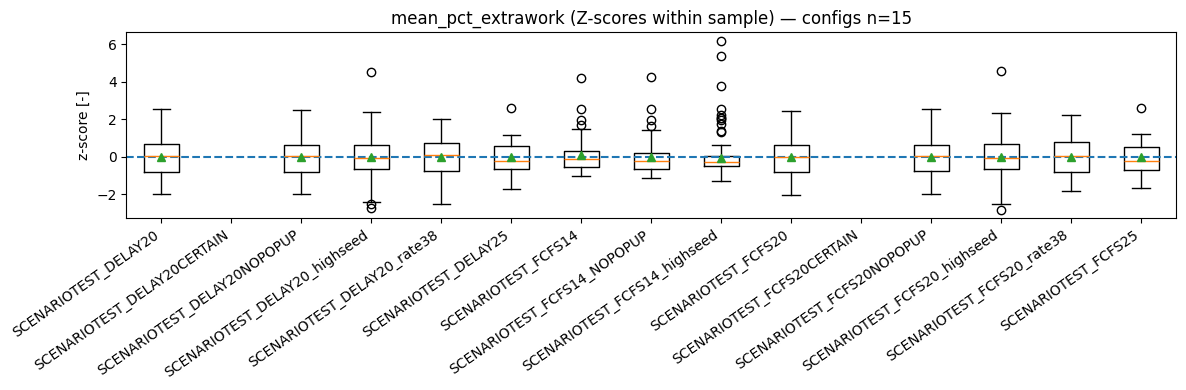

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


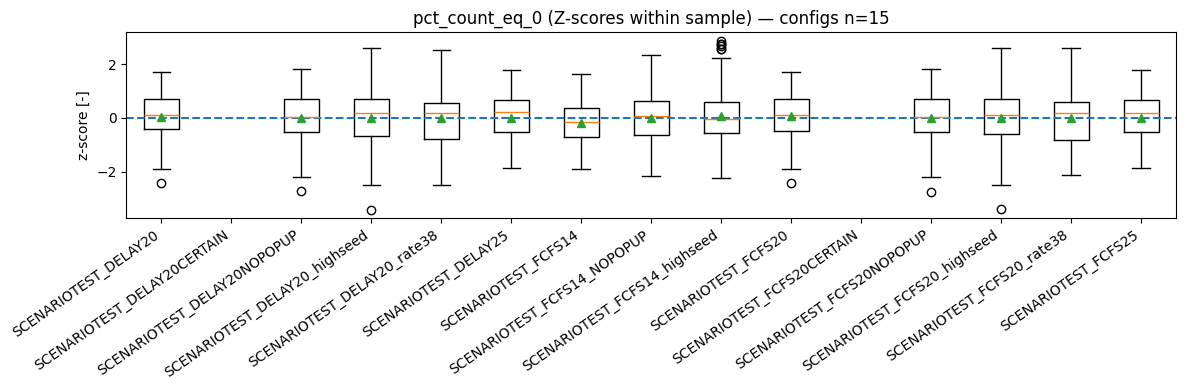

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


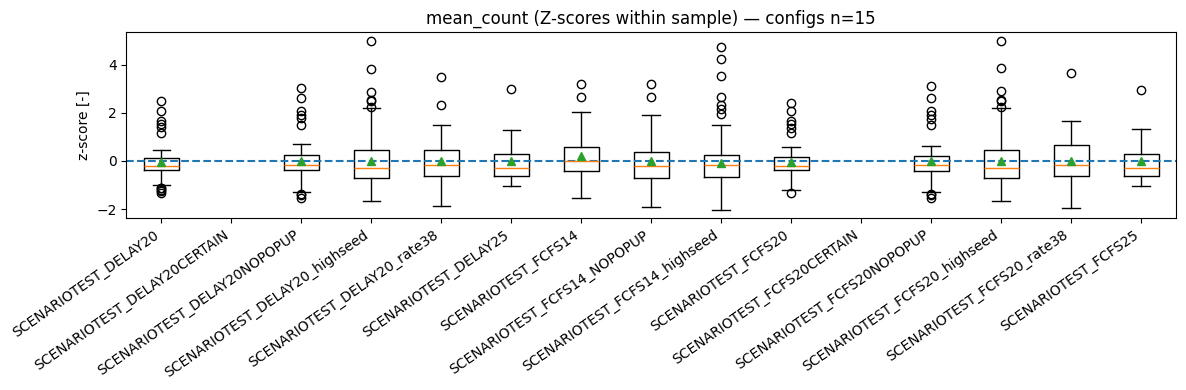

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


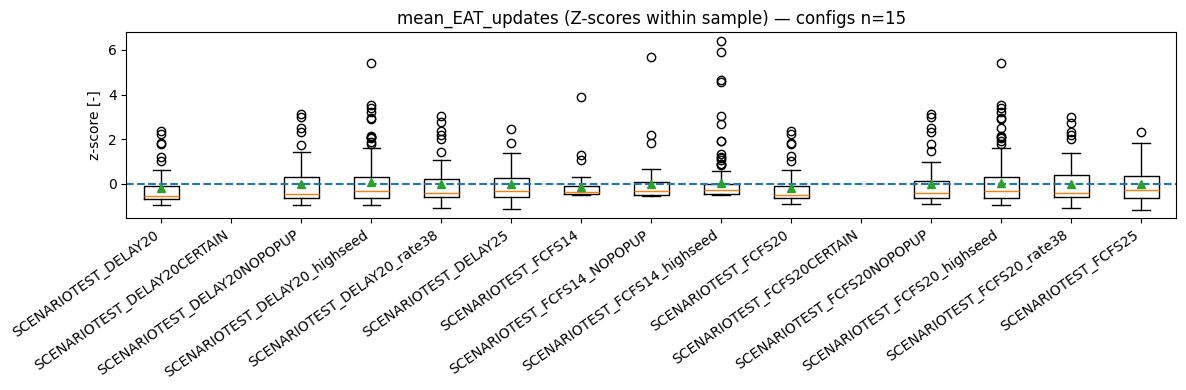

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


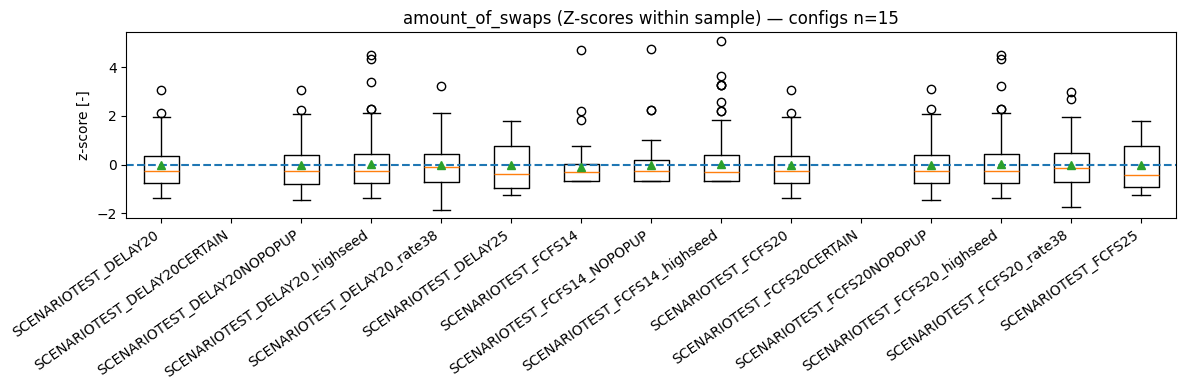

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


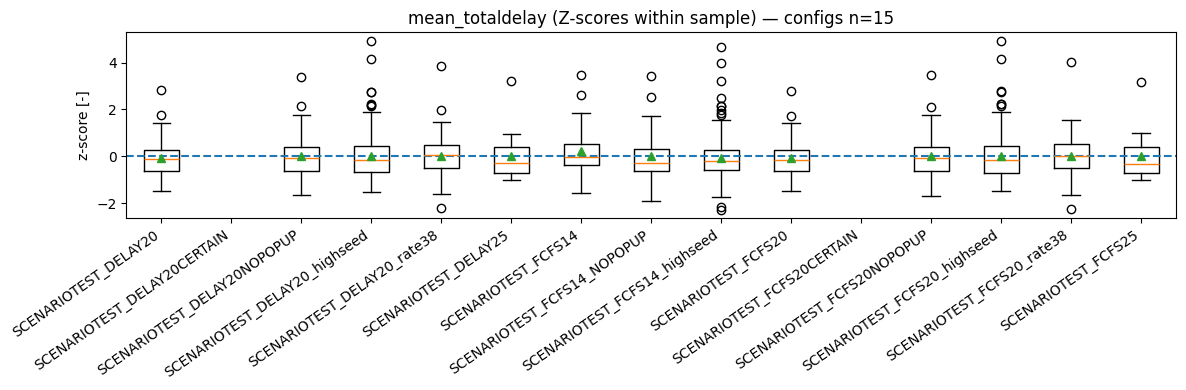

/var/folders/vw/drhksrbn55d6rwc088sbwpcw0000gn/T/ipykernel_81800/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


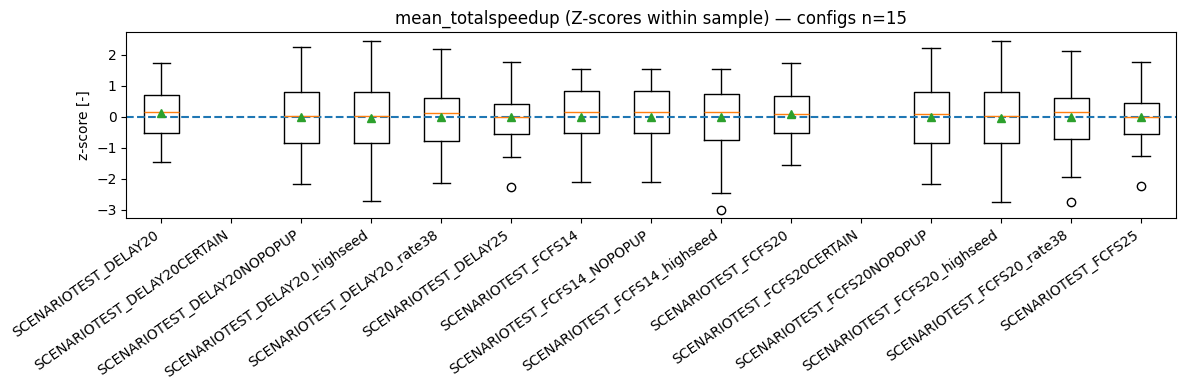

In [29]:
# === Cell 5: Boxplots (per measure) met selectie van configuraties ===
# Vereist: df_z bestaat en bevat kolommen: "condition", en per measure: f"{measure}_z"
# Vereist: MEASURES bestaat (list van measures)

# --- Selecties ---
SELECTED_MEASURES = MEASURES              # of bv ["LLDA", "extrawork"]
SELECTED_CONFIGS  = None                 # None = alle configs, of bv ["SCENARIOTEST_FCFS20", "SCENARIOTEST_DELAY20"]
ORDER_CONFIGS     = None                 # None = automatisch sorteren, of zelfde lijst als SELECTED_CONFIGS voor vaste volgorde

SHOW_MEANS = True
FIGSIZE = (12, 4)

def boxplots_zscores_configs(
    df_long: pd.DataFrame,
    measures: list[str],
    configs: list[str] | None = None,
    order: list[str] | None = None,
    cond_col: str = "condition",
):
    # filter configs
    d0 = df_long.copy()
    if configs is not None:
        d0 = d0[d0[cond_col].isin(configs)].copy()

    if order is None:
        conds = sorted(d0[cond_col].dropna().unique())
    else:
        conds = [c for c in order if c in set(d0[cond_col].dropna().unique())]

    if not conds:
        raise ValueError("No conditions left after filtering. Check SELECTED_CONFIGS / ORDER_CONFIGS.")

    for m in measures:
        zc = m + "_z"
        if zc not in d0.columns:
            print(f"SKIP {m}: missing column {zc}")
            continue

        d = d0[[cond_col, zc]].dropna().copy()
        groups = [d.loc[d[cond_col] == c, zc].to_numpy() for c in conds]

        plt.figure(figsize=FIGSIZE)
        plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)
        plt.axhline(0.0, linestyle="--")
        plt.title(f"{m} (Z-scores within sample) — configs n={len(conds)}")
        plt.ylabel("z-score [-]")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

boxplots_zscores_configs(
    df_z,
    measures=SELECTED_MEASURES,
    configs=SELECTED_CONFIGS,
    order=ORDER_CONFIGS,
)

In [30]:
# === Cell (optional): Combined long-format table for reporting ===
# Median/mean of z-scores per condition, per measure
z_summary = (
    df_z.groupby("condition")[ZCOLS]
      .agg(["mean", "median", "std", "count"])
      .sort_index()
)
z_summary

mean_pct_extrawork_z                           pct_count_eq_0_z                            mean_count_z                      \
                                              mean    median       std count             mean    median       std count          mean    median       std   
condition                                                                                                                                                   
SCENARIOTEST_DELAY20                 -1.614728e-02  0.066258  1.008935    48     5.047978e-02  0.094220  0.907899    48 -5.633603e-02 -0.199561  0.832359   
SCENARIOTEST_DELAY20CERTAIN                    NaN       NaN       NaN     0              NaN       NaN       NaN     0           NaN       NaN       NaN   
SCENARIOTEST_DELAY20NOPOPUP           5.504856e-16  0.039426  1.010582    48    -7.817820e-16  0.046322  1.010582    48 -6.985153e-16 -0.171153  1.010582   
SCENARIOTEST_DELAY20_highseed         5.420065e-03 -0.072285  1.004005   143    -1.694426e-02  0.194198  1.034937   143  1.891000e-02 -0.309266  1.055615   
SCENARIOTEST_DELAY20_rate38          -1.896631e-16  0.106675  1.010582    48    -4.926615e-16  0.188464  1.010582    48 -2.567391e-16 -0.178100  1.010582   
SCENARIOTEST_DELAY25                 -1.110223e-16 -0.194177  1.032796    16    -5.993470e-16  0.201704  1.032796    16 -3.608225e-16 -0.299869  1.032796   
SCENARIOTEST_FCFS14                   1.058180e-01 -0.115734  0.979608    48    -2.075181e-01 -0.149068  0.794241    48  2.240178e-01  0.013110  0.933286   
SCENARIOTEST_FCFS14_NOPOPUP          -1.850372e-17 -0.232737  1.010582    48     3.932040e-17  0.071590  1.010582    48 -1.341519e-16 -0.204291  1.010582   
SCENARIOTEST_FCFS14_highseed         -3.551934e-02 -0.244120  1.011133   143     6.965641e-02 -0.045155  1.056804   143 -7.519479e-02 -0.159574  1.016915   
SCENARIOTEST_FCFS20                  -2.270048e-02  0.012179  1.002616    48     5.249070e-02  0.096162  0.913921    48 -5.627370e-02 -0.200669  0.829562   
SCENARIOTEST_FCFS20CERTAIN                     NaN       NaN       NaN     0              NaN       NaN       NaN     0           NaN       NaN       NaN   
SCENARIOTEST_FCFS20NOPOPUP            5.181041e-16  0.075123  1.010582    48    -7.262709e-16  0.048687  1.010582    48 -4.625929e-17 -0.172733  1.010582   
SCENARIOTEST_FCFS20_highseed          7.619741e-03 -0.053517  1.006041   143    -1.761926e-02  0.096162  1.033136   143  1.888908e-02 -0.286086  1.056345   
SCENARIOTEST_FCFS20_rate38           -3.689179e-16  0.053907  1.010582    48    -8.187895e-16  0.183247  1.010582    48  2.937465e-16 -0.168860  1.010582   
SCENARIOTEST_FCFS25                  -2.324529e-16 -0.196220  1.032796    16    -2.975051e-16  0.165650  1.032796    16  8.673617e-17 -0.294669  1.032796   

                                    mean_EAT_updates_z                           amount_of_swaps_z                           mean_totaldelay_z            \
                              count               mean    median       std count              mean    median       std count              mean    median   
condition                                                                                                                                                  
SCENARIOTEST_DELAY20             48      -1.828849e-01 -0.527239  0.823704    48     -1.216596e-02 -0.270355  0.964863    48     -7.345049e-02 -0.130621   
SCENARIOTEST_DELAY20CERTAIN       0                NaN       NaN       NaN     0               NaN       NaN       NaN     0               NaN       NaN   
SCENARIOTEST_DELAY20NOPOPUP      48       4.625929e-18 -0.434204  1.010582    48      1.879284e-18 -0.284368  1.010582    48     -4.163336e-17 -0.062035   
SCENARIOTEST_DELAY20_highseed   143       6.138796e-02 -0.322699  1.051380   143      4.083678e-03 -0.270355  1.018268   143      2.465471e-02 -0.156049   
SCENARIOTEST_DELAY20_rate38      48       1.410908e-16 -0.392038  1.010582    48     -1.069746e-16 -0.103005  1

In [32]:
# === Friedman ANOVA  ===
# df: main dataframe
# seed_col: column with the paired samples (same seeds across configs)
# config_col: column with the config/condition label
# configs: list with configs you want to compare (and their order)
# measures: list of metric columns to test

seed_col   = "seed"        # <-- change
config_col = "condition"   # <-- change
configs    = ["SCENARIOTEST_DELAY20", "SCENARIOTEST_FCFS20", "SCENARIOTEST_FCFS14"]  # <-- change
measures   = MEASURES

# 1) filter + keep only seeds present in all selected configs (paired)
d = df[df[config_col].isin(configs)].copy()
common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col].astype(str)) for c in configs])
d[seed_col] = d[seed_col].astype(str)
d = d[d[seed_col].isin(common_seeds)].copy()

# 2) z-scores within seed (optional, but matches your earlier approach)
for m in measures:
    d[m] = pd.to_numeric(d[m], errors="coerce")
    mu = d.groupby(seed_col)[m].transform("mean")
    sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
    d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)

# 3) run friedman per measure on the wide z-score matrix
rows = []
for m in measures:
    zc = m + "_z"
    wide = d.pivot_table(index=seed_col, columns=config_col, values=zc, aggfunc="mean")
    wide = wide[configs].dropna(axis=0, how="any")  # enforce order + complete cases

    arrays = [wide[c].to_numpy() for c in wide.columns]
    chi2, p = stats.friedmanchisquare(*arrays)

    n, k = wide.shape
    W = chi2 / (n * (k - 1))  # Kendall's W

    rows.append({"measure": m, "chi2": float(chi2), "p": float(p), "n": int(n), "k": int(k), "kendall_W": float(W)})

friedman_results = pd.DataFrame(rows).sort_values("p")
friedman_results

,measure,chi2,p,n,k,kendall_W
3,mean_EAT_updates,84.092715,5.489072e-19,48,3,0.875966
6,mean_totalspeedup,83.277108,8.252883e-19,48,3,0.867470
4,amount_of_swaps,82.397163,1.281396e-18,46,3,0.895621
0,mean_pct_extrawork,66.166667,4.286382e-15,48,3,0.689236
5,mean_totaldelay,53.200000,2.803928e-12,48,3,0.554167
2,mean_count,50.180645,1.268853e-11,48,3,0.522715
1,pct_count_eq_0,34.859259,2.694065e-08,44,3,0.396128


In [33]:

alpha      = 0.05

# 1) zelfde preprocessing als Friedman
d = df[df[config_col].isin(configs)].copy()
d[seed_col] = d[seed_col].astype(str)

common_seeds = set.intersection(
    *[set(d.loc[d[config_col] == c, seed_col]) for c in configs]
)
d = d[d[seed_col].isin(common_seeds)].copy()

# 2) z-scores binnen seed
for m in measures:
    d[m] = pd.to_numeric(d[m], errors="coerce")
    mu = d.groupby(seed_col)[m].transform("mean")
    sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
    d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)

# 3) Wilcoxon pairwise
rows = []
pairs = [(configs[i], configs[j]) for i in range(len(configs)) for j in range(i+1, len(configs))]

for m in measures:
    zc = m + "_z"
    wide = d.pivot_table(index=seed_col, columns=config_col, values=zc, aggfunc="mean")
    wide = wide[configs].dropna(axis=0, how="any")

    for a, b in pairs:
        x = wide[a].to_numpy()
        y = wide[b].to_numpy()

        stat, p = stats.wilcoxon(x, y)
        rows.append({
            "measure": m,
            "config_A": a,
            "config_B": b,
            "p_raw": p,
            "median_diff": np.median(x - y),
            "n": len(x)
        })

posthoc = pd.DataFrame(rows)

# 4) Bonferroni correctie
posthoc["p_adj"] = posthoc["p_raw"] * len(pairs)
posthoc["significant"] = posthoc["p_adj"] < alpha

posthoc.sort_values(["measure", "p_adj"])


,measure,config_A,config_B,p_raw,median_diff,n,p_adj,significant
13,amount_of_swaps,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS14,4.803269e-12,2.121320,46,1.440981e-11,True
14,amount_of_swaps,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS14,5.883294e-12,2.121320,46,1.764988e-11,True
12,amount_of_swaps,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS20,1.000000e+00,0.000000,46,3.000000e+00,False
10,mean_EAT_updates,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS14,1.687539e-11,2.121320,48,5.062617e-11,True
11,mean_EAT_updates,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS14,1.964651e-11,2.121320,48,5.893952e-11,True
9,mean_EAT_updates,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS20,1.000000e+00,0.000000,48,3.000000e+00,False
8,mean_count,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS14,3.261327e-07,-2.121320,48,9.783980e-07,True
7,mean_count,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS14,1.754109e-05,-2.121320,48,5.262328e-05,True
6,mean_count,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS20,5.937117e-01,0.000000,48,1.781135e+00,False
1,mean_pct_extrawork,SCENARIOTEST_DELAY20,SCENARIOTEST_FCFS14,7.815970e-13,-2.120880,48,2.344791e-12,True


In [14]:
df.keys()

Index(['scenario', 'run', 'seed', 'usecache', 'node', 'status', 'maxtime', 'starttime', 'endtime', 'elapsed', 'mean_pct_extrawork', 'freezehorizon',
       'popup_planner', 'error_multiplicator', 'capacity', 'pct_count_eq_0', 'mean_count', 'mean_count_nonzero', 'max_count', 'second_highest_count',
       'max_count_acid', 'min_count_holding', 'mean_count_holding', 'max_count_holding', 'count_popup', 'count_fh_margin_at_freeze', 'min_fh_margin_at_freeze',
       'mean_fh_margin_at_freeze', 'max_fh_margin_at_freeze', 'min_EAT_updates', 'mean_EAT_updates', 'max_EAT_updates', 'mean_EAT_updates_nonzero',
       'min_swaps', 'mean_swaps', 'max_swaps', 'mean_swaps_nonzero', 'amount_of_swaps', 'min_ttlg_at_freeze', 'mean_ttlg_at_freeze', 'median_ttlg_at_freeze',
       'max_ttlg_at_freeze', 'mean_abs_ttlg_at_freeze', 'mean_E_TO', 'mean_abs_E_TO', 'min_E_TO', 'max_E_TO', 'mean_totaldelay', 'max_totaldelay',
       'mean_totaldelay_nonzero', 'min_totalspeedup', 'mean_totalspeedup', 'mean_totalsp

In [24]:
df.groupby("condition")["run"].nunique()

condition
SCENARIOTEST_DELAY20              48
SCENARIOTEST_DELAY20CERTAIN        1
SCENARIOTEST_DELAY20NOPOPUP       48
SCENARIOTEST_DELAY20_highseed    144
SCENARIOTEST_DELAY20_rate38       48
SCENARIOTEST_DELAY25              16
SCENARIOTEST_FCFS14               48
SCENARIOTEST_FCFS14_NOPOPUP       48
SCENARIOTEST_FCFS14_highseed     144
SCENARIOTEST_FCFS20               48
SCENARIOTEST_FCFS20CERTAIN         1
SCENARIOTEST_FCFS20NOPOPUP        48
SCENARIOTEST_FCFS20_highseed     144
SCENARIOTEST_FCFS20_rate38        48
SCENARIOTEST_FCFS25               16
Name: run, dtype: int64

In [15]:
# === Cell (optional): flag significant results at alpha ===
alpha = 0.05
friedman_results.assign(significant=lambda d: d["p"] < alpha)

,measure,chi2,p,n_samples,k_conditions,kendall_W,conditions,note,significant
0,mean_pct_extrawork,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
1,pct_count_eq_0,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
2,mean_count,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
3,mean_EAT_updates,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
4,mean_swaps,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
5,amount_of_swaps,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
6,mean_totaldelay,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False
7,mean_totalspeedup,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample...",False


In [40]:
# === Cell: Planned post-hoc Wilcoxon signed-rank tests (+ correction) ===
# Assumes:
# - df_z exists
# - MEASURES exists
# - each measure has a z-column: f"{measure}_z"
# - columns: sample_id, condition

# EDIT: planned comparisons (as in the report / your design)
PLANNED_PAIRS = [
    ("A/100", "A/0"),
    ("A/100", "A/200"),
    ("E/100", "E/0"),
    ("E/100", "E/200"),
    ("A/100", "E/100"),
]

CORRECTION = "bonferroni"  # "bonferroni" or "holm"
ALTERNATIVE = "two-sided"  # "two-sided", "greater", "less"

def wilcoxon_posthoc(df_long: pd.DataFrame,
                     measures: list[str],
                     pairs: list[tuple[str, str]],
                     correction: str = "bonferroni",
                     alternative: str = "two-sided",
                     order: list[str] | None = None) -> pd.DataFrame:
    rows = []

    for m in measures:
        zc = m + "_z"
        wide = to_wide(df_long, zc)

        # optional: enforce order subset
        if order is not None:
            cols = [c for c in order if c in wide.columns]
            wide = wide[cols].dropna(axis=0, how="any")

        for a, b in pairs:
            if a not in wide.columns or b not in wide.columns:
                continue

            x = wide[a].to_numpy()
            y = wide[b].to_numpy()

            # wilcoxon needs paired observations
            if len(x) < 3:
                continue

            stat, p = stats.wilcoxon(
                x, y,
                zero_method="wilcox",    # drop zero diffs
                alternative=alternative,
                mode="auto"
            )

            d = x - y
            rows.append({
                "measure": m,
                "pair": f"{a} vs {b}",
                "n": int(len(d)),
                "stat": float(stat),
                "p_raw": float(p),
                "mean_diff_z": float(np.mean(d)),
                "median_diff_z": float(np.median(d)),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    method = "bonferroni" if correction.lower() == "bonferroni" else "holm"
    reject, p_adj, _, _ = multipletests(out["p_raw"].to_numpy(), method=method)

    out["p_adj"] = p_adj
    out["reject"] = reject
    return out.sort_values(["measure", "p_adj", "p_raw"])

posthoc = wilcoxon_posthoc(
    df_z, MEASURES, PLANNED_PAIRS,
    correction=CORRECTION,
    alternative=ALTERNATIVE,
    order=ORDER,  # can be None
)

posthoc

""


In [41]:
# === Cell: Pretty summary per measure (which pairs significant) ===
alpha = 0.05
sig = posthoc[posthoc["p_adj"] < alpha].copy()

summary_pairs = (
    sig.groupby("measure")["pair"]
       .apply(list)
       .rename("significant_pairs")
)

summary = friedman_results.merge(summary_pairs, on="measure", how="left")
summary["significant_pairs"] = summary["significant_pairs"].apply(lambda x: x if isinstance(x, list) else [])
summary

KeyError: 'p_adj'

In [32]:
# === Cell (optional): export tables ===
OUTDIR = Path("stat_results")
OUTDIR.mkdir(exist_ok=True)

friedman_results.to_csv(OUTDIR / "friedman_main_effects.csv", index=False)
posthoc.to_csv(OUTDIR / f"wilcoxon_posthoc_{CORRECTION}.csv", index=False)
summary.to_csv(OUTDIR / f"summary_{CORRECTION}.csv", index=False)

print("Wrote:", OUTDIR.resolve())

NameError: name 'summary' is not defined